<a href="https://colab.research.google.com/github/HariniAnandkumar/neuromorphic-ai-research/blob/main/Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

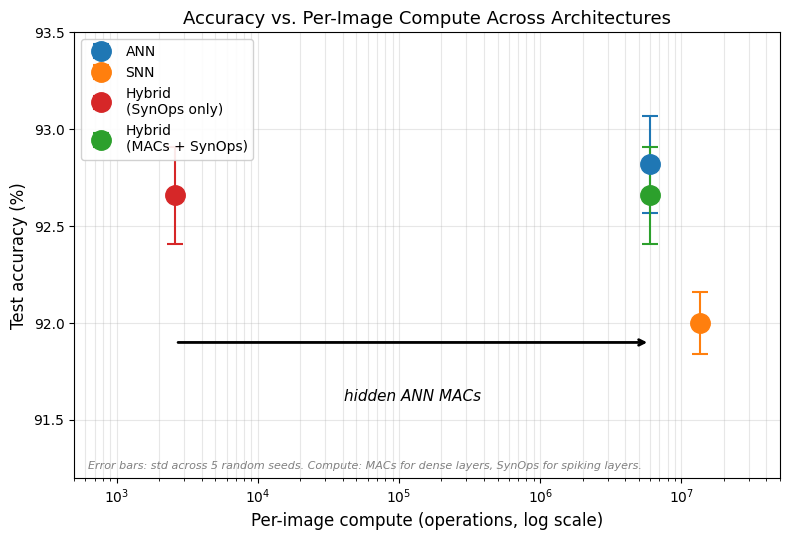

Files saved: accuracy_vs_compute.png and accuracy_vs_compute.pdf
Download from Colab file panel on the left


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['ANN', 'SNN', 'Hybrid\n(SynOps only)', 'Hybrid\n(MACs + SynOps)']
compute = [6_000_000, 13_500_000, 2_602, 6_002_602]
accuracy = [92.82, 92.00, 92.66, 92.66]
std = [0.25, 0.16, 0.25, 0.25]

# Colors
colors = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']

# Create figure
fig, ax = plt.subplots(figsize=(8, 5.5))

# Plot each point with error bars
for i, (m, c, a, s, col) in enumerate(zip(models, compute, accuracy, std, colors)):
    ax.errorbar(c, a, yerr=s, fmt='o', markersize=14, color=col,
                capsize=6, capthick=1.5, elinewidth=1.5, label=m, zorder=3)

# Draw arrow between the two Hybrid points to show hidden MAC cost
ax.annotate('', xy=(6_002_602, 91.9), xytext=(2_602, 91.9),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(np.sqrt(2_602 * 6_002_602), 91.6, 'hidden ANN MACs',
        ha='center', fontsize=11, style='italic')

# Formatting
ax.set_xscale('log')
ax.set_xlabel('Per-image compute (operations, log scale)', fontsize=12)
ax.set_ylabel('Test accuracy (%)', fontsize=12)
ax.set_title('Accuracy vs. Per-Image Compute Across Architectures', fontsize=13)
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(91.2, 93.5)
ax.set_xlim(500, 5e7)

# Legend
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

# Add reference annotation
ax.text(0.02, 0.02, 'Error bars: std across 5 random seeds. Compute: MACs for dense layers, SynOps for spiking layers.',
        transform=ax.transAxes, fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.savefig('accuracy_vs_compute.png', dpi=300, bbox_inches='tight')
plt.savefig('accuracy_vs_compute.pdf', bbox_inches='tight')
plt.show()

print("Files saved: accuracy_vs_compute.png and accuracy_vs_compute.pdf")
print("Download from Colab file panel on the left")